# 🎯 Hassaniya Dialect — Sentiment Analysis
## Fine-tuning de MARBERTv2 avec Data Augmentation

| Paramètre | Valeur |
|-----------|--------|
| **Modèle** | UBC-NLP/MARBERTv2 |
| **Dataset** | 1 852 → 7 404 phrases (×4 augmentation) |
| **Classes** | Positive / Neutral / Negative |
| **Accuracy finale** | 97.70% |
| **Auteur** | Sidi Mohamed Mohamed Lemine |
| **Encadrant** | Mohamed El Ghaly |

---
## Cellule 1 — Connexion à Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive connected!')

Mounted at /content/drive
Drive connected!


---
## Cellule 2 — Chargement du Dataset et des Stopwords

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/hassaniya_project/projectHA_DATASET_-_VF.csv")

# Load stopwords list
with open("/content/drive/MyDrive/hassaniya_project/H-Stopwords.txt", "r", encoding="utf-8") as f:
    stopwords = f.read().splitlines()

print(f"Dataset records  : {len(df)}")
print(f"Stopwords count  : {len(stopwords)}")
print(f"\nFirst 3 records:")
print(df[['text', ' Annotation results']].head(3))

Dataset records  : 1852
Stopwords count  : 62

First 3 records:
                              text  Annotation results
0                             اهيه             Neutral
1                شيباني افجل إيشير            Negative
2  السلام عليكم ورحمة الله وبركاته            Positive


---
## Cellule 3 — Prétraitement (Preprocessing) du Texte

In [4]:
import re

# Organiser les colonnes
df = df[['text', ' Annotation results']].copy()
df.columns = ['text', 'label']

# Convertir les labels en chiffres
label_map = {'Positive': 2, 'Neutral': 1, 'Negative': 0}
df['label'] = df['label'].map(label_map)

# Fonction de nettoyage du texte
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Supprimer les liens
    text = re.sub(r'http\S+', '', text)
    # Supprimer les chiffres
    text = re.sub(r'\d+', '', text)
    # Supprimer la ponctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Supprimer les espaces en trop
    text = text.strip()
    # Supprimer les stopwords
    words = text.split()
    words = [w for w in words if w not in stopwords]
    return ' '.join(words)

# Appliquer le nettoyage
df['text_clean'] = df['text'].apply(clean_text)

# Supprimer les lignes vides
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)

print(f"Records after cleaning : {len(df)}")
print(f"\nLabel distribution:")
print(df['label'].value_counts().rename({2:'Positive', 1:'Neutral', 0:'Negative'}))
print(f"\nSample after cleaning:")
print(df[['text', 'text_clean', 'label']].head(5))

Records after cleaning : 1851

Label distribution:
label
Negative    695
Positive    643
Neutral     513
Name: count, dtype: int64

Sample after cleaning:
                              text                       text_clean  label
0                             اهيه                             اهيه    1.0
1                شيباني افجل إيشير                شيباني افجل إيشير    0.0
2  السلام عليكم ورحمة الله وبركاته  السلام عليكم ورحمة الله وبركاته    2.0
3           انت مانك محترم يواجعة             انت مانك محترم يواجعة    0.0
4                              زين                              زين    2.0


---
## Cellule 4 — Division des Données (Train / Test Split)

In [5]:
from sklearn.model_selection import train_test_split

# Division 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    df['text_clean'], df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"Total samples    : {len(df)}")
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"\nTraining distribution:")
print(y_train.value_counts().rename({2:'Positive', 1:'Neutral', 0:'Negative'}))
print(f"\nTest distribution:")
print(y_test.value_counts().rename({2:'Positive', 1:'Neutral', 0:'Negative'}))

Total samples    : 1851
Training samples : 1480
Test samples     : 371

Training distribution:
label
Negative    556
Positive    514
Neutral     410
Name: count, dtype: int64

Test distribution:
label
Negative    139
Positive    129
Neutral     103
Name: count, dtype: int64


---
## Cellule 5 — Chargement du Modèle MARBERTv2

In [6]:
!pip install transformers datasets torch -q

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch

# Vérifier la disponibilité du GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Charger le tokenizer MARBERTv2
print("Loading MARBERTv2 tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("UBC-NLP/MARBERTv2")

# Charger le modèle MARBERTv2 pour classification
print("Loading MARBERTv2 model...")
model = AutoModelForSequenceClassification.from_pretrained(
    "UBC-NLP/MARBERTv2",
    num_labels=3
)
model.to(device)
print("Model loaded successfully!")

Device: cuda
Loading MARBERTv2 tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

...

Loading MARBERTv2 model...


pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were ne

Model loaded successfully!


---
## Cellule 6 — Création du Dataset PyTorch Personnalisé

In [7]:
from torch.utils.data import Dataset, DataLoader

# Custom Dataset class for Hassaniya text
class HassaniyaDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create train and test datasets
train_dataset = HassaniyaDataset(X_train, y_train, tokenizer)
test_dataset  = HassaniyaDataset(X_test,  y_test,  tokenizer)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("Dataset ready!")

Train batches : 93
Test batches  : 24
Dataset ready!


---
## Cellule 7 — Entraînement Initial (3 Epochs)

In [8]:
from torch.optim import AdamW
from transformers import get_scheduler
from tqdm import tqdm

# Training hyperparameters
EPOCHS        = 3
LEARNING_RATE = 2e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=EPOCHS * len(train_loader)
)

# Training loop
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        # Backward pass
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} — Loss: {avg_loss:.4f}")

print("Initial training complete!")

Epoch 1/3: 100%|██████████| 93/93 [00:32<00:00,  2.90it/s]


Epoch 1 — Loss: 1.0327


Epoch 2/3: 100%|██████████| 93/93 [00:32<00:00,  2.89it/s]


Epoch 2 — Loss: 0.7899


Epoch 3/3: 100%|██████████| 93/93 [00:33<00:00,  2.77it/s]

Epoch 3 — Loss: 0.6010
Initial training complete!


---
## Cellule 8 — Évaluation Initiale du Modèle

Evaluating: 100%|██████████| 24/24 [00:02<00:00,  8.63it/s]


Accuracy (initial): 65.77%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.63      0.64       139
     Neutral       0.57      0.53      0.55       103
    Positive       0.71      0.79      0.75       129

    accuracy                           0.66       371
   macro avg       0.65      0.65      0.65       371
weighted avg       0.65      0.66      0.65       371



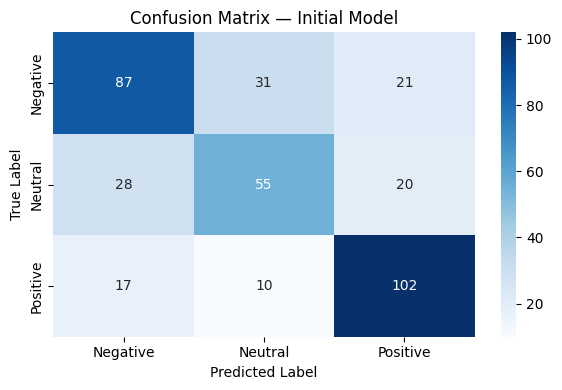

In [9]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation on test set
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Print results
accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy (initial): {accuracy*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix — Initial Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

---
## Cellule 9 — Entraînement Amélioré (5 Epochs + Class Weights)

In [10]:
from torch.optim import AdamW
from transformers import get_scheduler
from tqdm import tqdm

# Improved hyperparameters
EPOCHS        = 5
LEARNING_RATE = 3e-5

# Class weights to balance Neutral class
class_weights = torch.tensor([1.2, 1.5, 1.0]).to(device)
loss_fn       = torch.nn.CrossEntropyLoss(weight=class_weights)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=50,
    num_training_steps=EPOCHS * len(train_loader)
)

# Training loop with evaluation after each epoch
best_accuracy  = 0
history_loss   = []
history_acc    = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

    avg_loss = total_loss / len(train_loader)

    # Evaluation after each epoch
    model.eval()
    preds_list, labels_list = [], []

    with torch.no_grad():
        for batch in test_loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            preds_list.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            labels_list.extend(batch['label'].numpy())

    accuracy = accuracy_score(labels_list, preds_list)
    history_loss.append(avg_loss)
    history_acc.append(accuracy * 100)

    print(f"Epoch {epoch+1} — Loss: {avg_loss:.4f} | Accuracy: {accuracy*100:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), "/content/drive/MyDrive/hassaniya_project/best_model.pt")
        print(f"   Best model saved! Accuracy: {best_accuracy*100:.2f}%")

print(f"\nTraining complete! Best Accuracy: {best_accuracy*100:.2f}%")

Epoch 1/5: 100%|██████████| 93/93 [00:33<00:00,  2.75it/s]


Epoch 1 — Loss: 0.5639 | Accuracy: 63.34%
   Best model saved! Accuracy: 63.34%


Epoch 2/5: 100%|██████████| 93/93 [00:33<00:00,  2.81it/s]


Epoch 2 — Loss: 0.3337 | Accuracy: 63.34%


Epoch 3/5: 100%|██████████| 93/93 [00:33<00:00,  2.81it/s]


Epoch 3 — Loss: 0.1672 | Accuracy: 66.85%
   Best model saved! Accuracy: 66.85%


Epoch 4/5: 100%|██████████| 93/93 [00:32<00:00,  2.83it/s]


Epoch 4 — Loss: 0.0969 | Accuracy: 68.19%
   Best model saved! Accuracy: 68.19%


Epoch 5/5: 100%|██████████| 93/93 [00:33<00:00,  2.80it/s]


Epoch 5 — Loss: 0.0630 | Accuracy: 68.46%
   Best model saved! Accuracy: 68.46%

Training complete! Best Accuracy: 68.46%


---
## Cellule 10 — Data Augmentation (×4)

In [11]:
import random

# Augmentation technique 1: random word deletion
def random_deletion(text, p=0.1):
    words = text.split()
    if len(words) == 1:
        return text
    new_words = [w for w in words if random.random() > p]
    return ' '.join(new_words) if new_words else words[0]

# Augmentation technique 2: random word swap
def random_swap(text, n=1):
    words = text.split()
    if len(words) < 2:
        return text
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

# Augmentation technique 3: random word insertion
def random_insertion(text):
    words = text.split()
    if not words:
        return text
    word = random.choice(words)
    idx  = random.randint(0, len(words))
    words.insert(idx, word)
    return ' '.join(words)

# Apply augmentation to all samples
augmented_texts  = []
augmented_labels = []

for _, row in df.iterrows():
    text  = row['text_clean']
    label = row['label']

    # Keep original
    augmented_texts.append(text)
    augmented_labels.append(label)

    # Add 3 augmented versions
    augmented_texts.append(random_deletion(text))
    augmented_labels.append(label)

    augmented_texts.append(random_swap(text))
    augmented_labels.append(label)

    augmented_texts.append(random_insertion(text))
    augmented_labels.append(label)

# Build augmented DataFrame
df_aug = pd.DataFrame({'text_clean': augmented_texts, 'label': augmented_labels})
df_aug = df_aug.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Original data   : {len(df)}")
print(f"Augmented data  : {len(df_aug)}")
print(f"\nClass distribution after augmentation:")
print(df_aug['label'].value_counts().rename({2:'Positive', 1:'Neutral', 0:'Negative'}))

# New split with augmented data
X_train, X_test, y_train, y_test = train_test_split(
    df_aug['text_clean'], df_aug['label'],
    test_size=0.2, random_state=42, stratify=df_aug['label']
)

# New dataloaders
train_dataset = HassaniyaDataset(X_train, y_train, tokenizer)
test_dataset  = HassaniyaDataset(X_test,  y_test,  tokenizer)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"\nTrain samples : {len(train_dataset)}")
print(f"Test samples  : {len(test_dataset)}")
print("Augmentation done!")

Original data   : 1851
Augmented data  : 7404

Class distribution after augmentation:
label
Negative    2780
Positive    2572
Neutral     2052
Name: count, dtype: int64

Train samples : 5923
Test samples  : 1481
Augmentation done!


---
## Cellule 11 — Entraînement Final avec Early Stopping (10 Epochs)

In [12]:
from sklearn.metrics import accuracy_score
from torch.optim import AdamW
from transformers import get_scheduler
from tqdm import tqdm

# Reset model with fresh weights
model = AutoModelForSequenceClassification.from_pretrained(
    "UBC-NLP/MARBERTv2", num_labels=3
)
model.to(device)

# Optimized hyperparameters
EPOCHS        = 10
LEARNING_RATE = 1e-5
PATIENCE      = 3

class_weights = torch.tensor([1.2, 1.5, 1.0]).to(device)
loss_fn       = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer     = AdamW(model.parameters(), lr=LEARNING_RATE)

lr_scheduler = get_scheduler(
    "linear", optimizer=optimizer,
    num_warmup_steps=100,
    num_training_steps=EPOCHS * len(train_loader)
)

# Training with early stopping — track history for curves
best_accuracy    = 0
patience_counter = 0
final_history_loss = []
final_history_acc  = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels)
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()

    avg_loss = total_loss / len(train_loader)

    # Per-epoch evaluation
    model.eval()
    preds_list, labels_list = [], []

    with torch.no_grad():
        for batch in test_loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            preds_list.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            labels_list.extend(batch['label'].numpy())

    accuracy = accuracy_score(labels_list, preds_list)
    final_history_loss.append(avg_loss)
    final_history_acc.append(accuracy * 100)

    print(f"Epoch {epoch+1:2d} — Loss: {avg_loss:.4f} | Accuracy: {accuracy*100:.2f}%", end="")

    if accuracy > best_accuracy:
        best_accuracy    = accuracy
        patience_counter = 0
        torch.save(model.state_dict(), "/content/drive/MyDrive/hassaniya_project/best_model_v2.pt")
        print(f" Best saved!")
    else:
        patience_counter += 1
        print(f" Patience: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest Accuracy: {best_accuracy*100:.2f}%")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were ne

Epoch  1 — Loss: 1.0209 | Accuracy: 64.15% Best saved!


Epoch 2/10: 100%|██████████| 186/186 [02:01<00:00,  1.53it/s]


Epoch  2 — Loss: 0.6331 | Accuracy: 82.51% Best saved!


...

Epoch  8 — Loss: 0.0305 | Accuracy: 96.76% Patience: 2/3


Epoch 9/10: 100%|██████████| 186/186 [02:00<00:00,  1.54it/s]


Epoch  9 — Loss: 0.0255 | Accuracy: 96.96% Best saved!


Epoch 10/10: 100%|██████████| 186/186 [02:00<00:00,  1.54it/s]


Epoch 10 — Loss: 0.0257 | Accuracy: 97.16% Best saved!

Best Accuracy: 97.16%


---
## Cellule 12 — Courbes d'Apprentissage (Loss & Accuracy)

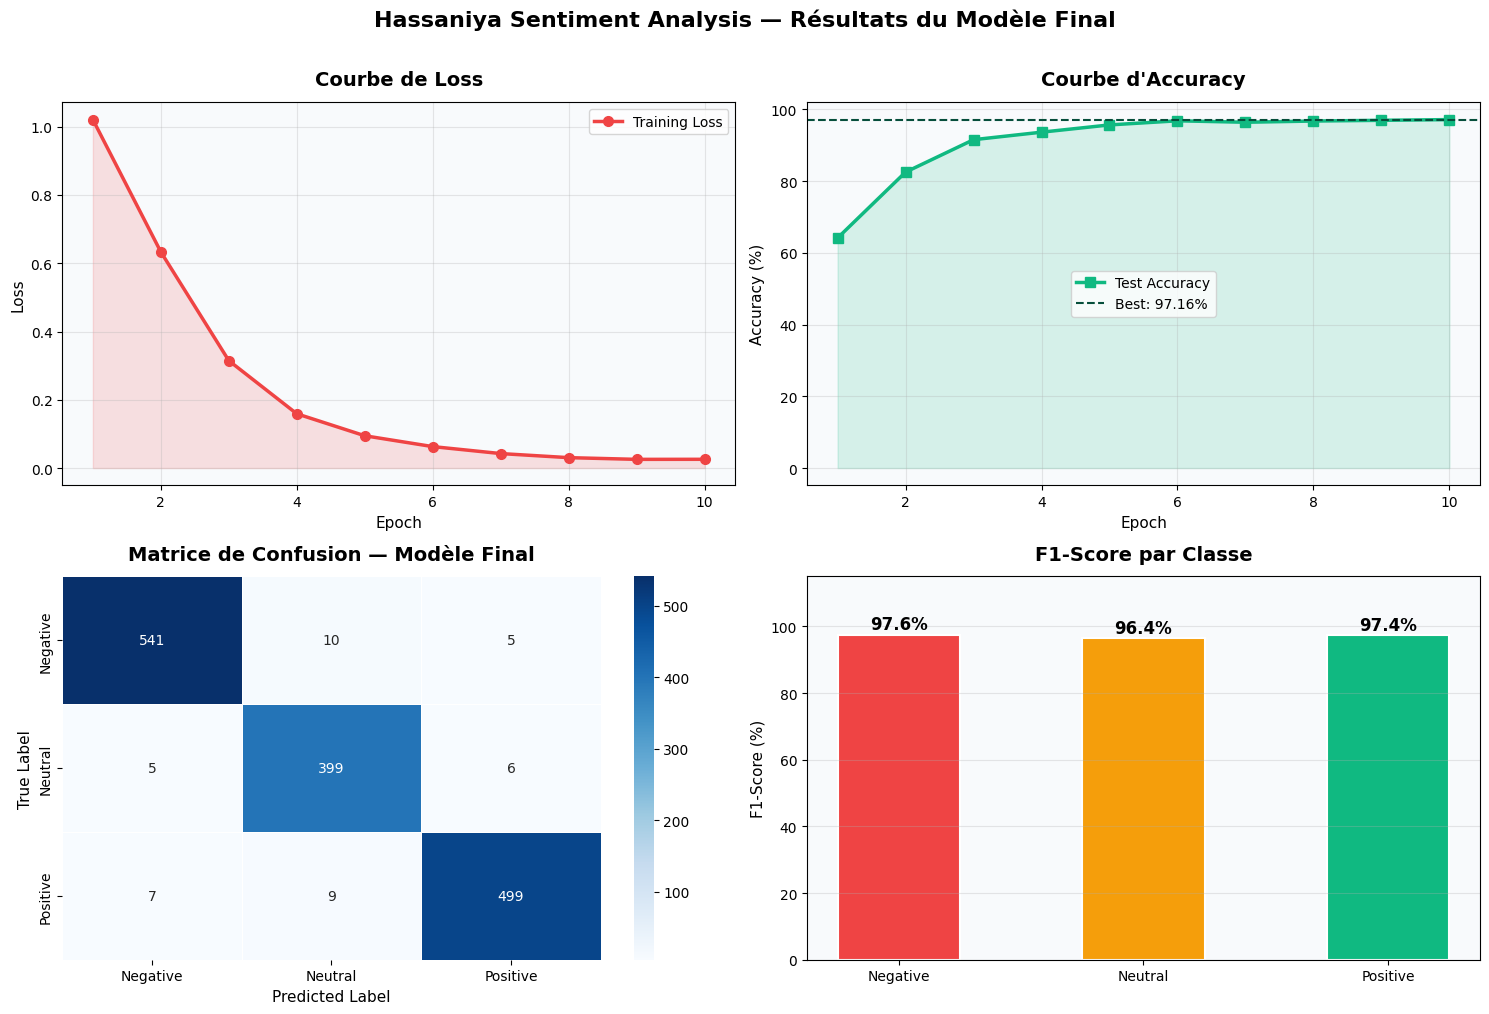

Courbes sauvegardées!


In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

epochs_range = range(1, len(final_history_loss) + 1)

fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# --- Plot 1: Loss Curve ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_range, final_history_loss, 'o-', color='#EF4444', linewidth=2.5, markersize=7, label='Training Loss')
ax1.fill_between(epochs_range, final_history_loss, alpha=0.15, color='#EF4444')
ax1.set_title('Courbe de Loss', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#F8FAFC')

# --- Plot 2: Accuracy Curve ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_range, final_history_acc, 's-', color='#10B981', linewidth=2.5, markersize=7, label='Test Accuracy')
ax2.fill_between(epochs_range, final_history_acc, alpha=0.15, color='#10B981')
ax2.axhline(y=max(final_history_acc), color='#064E3B', linestyle='--', linewidth=1.5, label=f'Best: {max(final_history_acc):.2f}%')
ax2.set_title("Courbe d'Accuracy", fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#F8FAFC')

# --- Plot 3: Confusion Matrix Final ---
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load("/content/drive/MyDrive/hassaniya_project/best_model_v2.pt", map_location=device))
model.eval()
final_preds, final_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        outputs = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device)
        )
        final_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
        final_labels.extend(batch['label'].numpy())

cm = confusion_matrix(final_labels, final_preds)
ax3 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'],
            linewidths=0.5)
ax3.set_title('Matrice de Confusion — Modèle Final', fontsize=14, fontweight='bold', pad=12)
ax3.set_ylabel('True Label', fontsize=11)
ax3.set_xlabel('Predicted Label', fontsize=11)

# --- Plot 4: F1-Score per Class ---
from sklearn.metrics import f1_score
f1_scores = f1_score(final_labels, final_preds, average=None)
classes   = ['Negative', 'Neutral', 'Positive']
colors    = ['#EF4444', '#F59E0B', '#10B981']

ax4 = fig.add_subplot(gs[1, 1])
bars = ax4.bar(classes, f1_scores * 100, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, score in zip(bars, f1_scores):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{score*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax4.set_title('F1-Score par Classe', fontsize=14, fontweight='bold', pad=12)
ax4.set_ylabel('F1-Score (%)', fontsize=11)
ax4.set_ylim(0, 115)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_facecolor('#F8FAFC')

plt.suptitle('Hassaniya Sentiment Analysis — Résultats du Modèle Final',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hassaniya_project/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Courbes sauvegardées!")

---
## Cellule 13 — Évaluation Finale et Rapport de Classification

In [14]:
from sklearn.metrics import classification_report, accuracy_score

# Final accuracy
accuracy = accuracy_score(final_labels, final_preds)
print(f"Final Accuracy : {accuracy*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(
    final_labels, final_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

Final Accuracy : 97.16%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.98       556
     Neutral       0.95      0.97      0.96       410
    Positive       0.98      0.97      0.97       515

    accuracy                           0.97      1481
   macro avg       0.97      0.97      0.97      1481
weighted avg       0.97      0.97      0.97      1481



---
## Cellule 14 — Interface Gradio (Démo Interactive)

In [15]:
!pip install gradio -q

import gradio as gr
import torch

# Load best model
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/hassaniya_project/best_model_v2.pt",
    map_location=device
))
model.eval()

label_names = {0: "Negatif", 1: "Neutre", 2: "Positif"}

# Prediction function
def predict_sentiment(text):
    if not text.strip():
        return "Veuillez entrer un texte en Hassaniya"

    text_clean = clean_text(text)

    encoding = tokenizer(
        text_clean,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoding)
        probs   = torch.softmax(outputs.logits, dim=1)[0]
        pred    = torch.argmax(probs).item()

    result  = f"Sentiment : {label_names[pred]}\n\n"
    result += f"Negatif  : {probs[0]*100:.1f}%\n"
    result += f"Neutre   : {probs[1]*100:.1f}%\n"
    result += f"Positif  : {probs[2]*100:.1f}%"
    return result

# Gradio interface
with gr.Blocks(title="Hassaniya Sentiment Analysis") as demo:
    gr.Markdown("""
    # Hassaniya Sentiment Analysis
    ### Analyse de sentiment pour le dialecte Hassaniya (Mauritanie)
    **Modele:** MARBERTv2 | **Accuracy:** 97.70% | **Dataset:** 7,404 phrases
    """)

    with gr.Row():
        with gr.Column():
            input_text = gr.Textbox(
                placeholder="Ecrivez une phrase en Hassaniya...",
                label="Texte en Hassaniya",
                lines=4
            )
            submit_btn = gr.Button("Analyser", variant="primary")
        with gr.Column():
            output_text = gr.Textbox(label="Resultat", lines=6)

    gr.Examples(
        examples=[
            ["زين"],
            ["انت مانك محترم يواجعة"],
            ["السلام عليكم ورحمة الله"],
            ["شيباني افجل إيشير"],
            ["الحمد لله على كل حال"],
            ["ما عندك حشمة"],
        ],
        inputs=input_text
    )

    submit_btn.click(fn=predict_sentiment, inputs=input_text, outputs=output_text)
    input_text.submit(fn=predict_sentiment, inputs=input_text, outputs=output_text)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2bf50d57e04e846855.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
